# Detectando Acessos suspeitos e Maliciosos em Aplicações WEB

Neste  projeto  vamos  realizar  um  extenso  trabalho  de  exploração  de  dados  a  fim  de detectar  acessos  suspeitos  e  ações  maliciosas  em  aplicações  web.  Faremos  isso  através  de diversas técnicas de análise. Ao final, criaremos um modelo preditivo.Usaremos dados fictícios que representam o arquivo de log de um servidor web

In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
pd.set_option('display.max_rows', 2500)
import warnings
warnings.filterwarnings('ignore')

In [2]:
dados = pd.read_csv('dataset.csv', delim_whitespace = True)
dados.columns

Index(['date', 'time', 's-ip', 'cs-method', 'cs-uri-stem', 'cs-uri-query',
       's-port', 'cs-username', 'c-ip', 'cs(User-Agent)', 'cs(Referer)',
       'sc-status', 'sc-substatus', 'sc-win32-status', 'time-taken'],
      dtype='object')

In [3]:
dados.sample(5)

,date,time,s-ip,cs-method,cs-uri-stem,cs-uri-query,s-port,cs-username,c-ip,cs(User-Agent),cs(Referer),sc-status,sc-substatus,sc-win32-status,time-taken
25977,2022-01-12,09:21:45,57.222.145.109,GET,index.aspx,-,443,-,164.39.167.71,Mozilla/4.0+(compatible;+MSIE+8.0;+Windows+NT+...,https://bankofpunk.local/login.aspx,301,0,0,24
57451,2022-01-25,13:42:40,57.222.145.109,GET,template.css,v=jflolsas,443,zg317106,45.10.223.124,Mozilla/4.0+(compatible;+MSIE+7.0;+Windows+NT+...,https://bankofpunk.local/transactions.aspx,200,0,0,22
34435,2022-01-15,21:22:00,57.222.145.109,GET,vpnwwlee.css,-,443,-,195.183.49.186,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,-,404,0,0,27
3266,2022-01-02,14:17:45,57.222.145.109,GET,main.css,-,443,-,209.182.154.146,Mozilla/4.0+(compatible;+MSIE+6.0;+Windows+NT+...,https://bankofpunk.local/index.aspx,200,0,0,25
57121,2022-01-25,12:44:41,57.222.145.109,GET,yzwcwwig.css,-,443,pm345541,213.199.170.4,Mozilla/4.0+(compatible;+MSIE+7.0;+Windows+NT+...,https://bankofpunk.local/account_status.aspx,200,0,0,29


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70315 entries, 0 to 70314
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             70315 non-null  object
 1   time             70315 non-null  object
 2   s-ip             70315 non-null  object
 3   cs-method        70315 non-null  object
 4   cs-uri-stem      70315 non-null  object
 5   cs-uri-query     70315 non-null  object
 6   s-port           70315 non-null  int64 
 7   cs-username      70315 non-null  object
 8   c-ip             70315 non-null  object
 9   cs(User-Agent)   70315 non-null  object
 10  cs(Referer)      70315 non-null  object
 11  sc-status        70315 non-null  int64 
 12  sc-substatus     70315 non-null  int64 
 13  sc-win32-status  70315 non-null  int64 
 14  time-taken       70315 non-null  int64 
dtypes: int64(5), object(10)
memory usage: 8.0+ MB


In [5]:
# Dicionário de dados
data_dict = {
    "date": "Data da requisição",
    "time": "Hora da requisição",
    "s-ip": "IP do servidor",
    "cs-method": "Método HTTP utilizado",
    "cs-uri-stem": "Caminho do recurso requisitado",
    "cs-uri-query": "Query string (se houver)",
    "s-port": "Porta do servidor",
    "cs-username": "Nome de usuário (se houver)",
    "c-ip": "IP do cliente",
    "cs(User-Agent)": "Agente do usuário",
    "cs(Referer)": "Referência",
    "sc-status": "Status HTTP",
    "sc-substatus": "Substatus HTTP",
    "sc-win32-status": "Status do Win32",
    "time-taken": "Tempo levado para a requisição",
}

### Análise 1 - Proxy Users Analysis (**cs(User-Agent)**)

O objetivo do campo **cs(User-Agent)** é especificar informações sobre o aplicativo cliente que está enviando a mensagem ao servidor web.

O campo cs(User-Agent) deve ser definido com o mesmo valor que o navegador web especifica no cabeçalho do protocolo HTTP. O campo pode ser definido de forma diferente, desde que siga a sintaxe ABNF 

Se uma mensagem for encaminhada por um proxy, o campo cs(User-Agent) deve começar com a string "_via_". O valor original especificado pelo cliente (que pode ser outro proxy) no campo cs(User-Agent) deve ser descartado. O proxy deve incluir um token no campo cs(User-Agent) que especifica a marca e a versão do proxy.

Vamos analisar a coluna **cs(User-Agent)** a fim de verificar se há algum uso de proxy ou não. Qualquer mensagem de login encaminhada pelo proxy, a palavra-chave '_via_' deve estar lá.

In [6]:
data_dict["cs(User-Agent)"]

'Agente do usuário'

In [8]:
# cria um dataframe vazio
analise1 = pd.DataFrame()

In [9]:
analise1["cs(User-Agent)"] = pd.DataFrame(dados['cs(User-Agent)'].unique())
analise1.shape

(152, 1)

In [10]:
analise1.head(5)

,cs(User-Agent)
0,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...
1,Mozilla/5.0+(Windows+NT+10.0)+AppleWebKit/537....
2,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...
3,Mozilla/5.0+(compatible;+MSIE+10.0;+Windows+NT...
4,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...


In [13]:
# Filtrando para ver se tem uso de proxy, se houver pode ser um indicio de acesso suspeito
# Par verificar ses ha proxy, procuramos a palavra "via"
analise1["Proxy_user"] = pd.DataFrame(dados['cs(User-Agent)'].str.contains("_via_"))
analise1.sample(5)

,cs(User-Agent),proxy_user,Proxy_user
30,"Mozilla/5.0+(compatible,+MSIE+11,+Windows+NT+6...",False,False
43,Mozilla/5.0+(compatible;+MSIE+10.0;+Windows+NT...,False,False
71,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,False,False
39,Mozilla/4.0+(compatible;+MSIE+7.0;+Windows+NT+...,False,False
128,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,False,False


In [14]:
analise1["Proxy_user"].value_counts()

Proxy_user
False    152
Name: count, dtype: int64

`Resultado da Análise:`

Nenhum user-agent usou proxy, pois a palavra-chave <b>via</b> não foi encontrada.

### Análise 2 - Anonymous Users Analysis

Vamos analisar o campo **cs-username**. Esse campo traz o nome do usuário acessando o servidor e se não for um usuário autenticado, será representado por um hífen.

Nesta análise a coluna **cs-username** será verificada para ver se existem usuários não autenticados, observando "-". 

In [15]:
data_dict["cs-username"]

'Nome de usuário (se houver)'

In [16]:
dados.sample(5)

,date,time,s-ip,cs-method,cs-uri-stem,cs-uri-query,s-port,cs-username,c-ip,cs(User-Agent),cs(Referer),sc-status,sc-substatus,sc-win32-status,time-taken
25091,2022-01-11,19:52:00,57.222.145.109,GET,index.aspx,-,443,-,195.212.101.122,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,-,200,0,0,29
58256,2022-01-25,20:20:28,57.222.145.109,GET,index.aspx,-,443,-,195.183.11.198,Mozilla/5.0+(Windows+NT+6.1;+Win64;+x64)+Apple...,https://bankofpunk.local/index.aspx,301,0,0,24
23752,2022-01-11,09:58:07,57.222.145.109,GET,index.aspx,-,443,-,185.177.72.150,Mozilla/4.0+(compatible;+MSIE+8.0;+Windows+NT+...,https://bankofpunk.local/index.aspx,200,0,0,21
48630,2022-01-21,21:58:34,57.222.145.109,GET,nyobbddm.css,-,443,jt503573,104.67.30.180,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+12_4_1+like...,https://bankofpunk.local/account_status.aspx,200,0,0,21
68336,2022-01-30,09:11:51,57.222.145.109,GET,template.css,v=lloipryn,443,-,193.53.166.126,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+12_0+like+M...,https://bankofpunk.local/index.aspx,200,0,0,23


In [18]:
analise2 = pd.DataFrame()

# Preenche o dataframe com o filtro no dataframe original buscando valores únicos na coluna
analise2["cs-username"] = pd.DataFrame(dados['cs-username'].unique())
analise2.shape

(1014, 1)

In [19]:
# Aplicamos o filtro e sobrescrevemos o dataframe analise2, lembrando que se o valor na coluna for um hifen, é um indicio de acesso suspeito
analise2 = dados[dados['cs-username'].str.contains("-")]
analise2['cs-username'].value_counts()

cs-username
-    27500
Name: count, dtype: int64

In [20]:
# Visualiza os acessos de usuários não autenticados
analise2.sample(5)

,date,time,s-ip,cs-method,cs-uri-stem,cs-uri-query,s-port,cs-username,c-ip,cs(User-Agent),cs(Referer),sc-status,sc-substatus,sc-win32-status,time-taken
64995,2022-01-28,21:56:17,57.222.145.109,GET,index.aspx,-,443,-,89.202.211.62,Mozilla/5.0+(compatible;+MSIE+10.0;+Windows+NT...,https://bankofpunk.local/index.aspx,200,0,0,28
14397,2022-01-07,09:49:34,57.222.145.109,GET,kuxscaqr.css,-,443,-,54.192.35.24,Mozilla/5.0+(compatible;+MSIE+9.0;+Windows+NT+...,https://bankofpunk.local/index.aspx,404,0,0,29
34372,2022-01-15,20:59:57,57.222.145.109,GET,login.aspx,-,443,-,40.94.84.166,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,https://bankofpunk.local/index.aspx,200,0,0,30
418,2022-01-01,09:44:47,57.222.145.109,GET,favico.ico,-,443,-,213.86.144.192,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+12_2+like+M...,https://bankofpunk.local/index.aspx,200,0,0,22
36143,2022-01-16,13:10:30,57.222.145.109,GET,index.aspx,-,443,-,83.137.228.112,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+13_4_1+like...,https://bankofpunk.local/index.aspx,301,0,0,27


`Resultado da Análise:`

O total de acessos de usuários não autenticados é baixo em relação ao total de acessos. Como isso não é garantia de acesso não suspeito ou malicioso, vamos seguir investigando.

### Análise 3 - Número de Solicitações Por IP do Cliente

Quais endereços IP de clientes tiveram maior volume de acessos? Isso pode indicar eventuais problemas ou anomalias.

Usando value_counts(), vamos tentar descobrir qualquer número incomum de solicitações de IPs de clientes. As contagens são representadas em ordem decrescente. Usaremos a coluna **c-ip** (client IP).

In [21]:
data_dict["c-ip"]

'IP do cliente'

In [22]:
analise3 = pd.DataFrame()

analise3["Count-Client-IP"] = pd.value_counts(dados['c-ip']).head(10)
analise3

,Count-Client-IP
c-ip,
103.211.182.34,244
217.15.114.98,144
82.206.244.38,143
185.97.213.168,141
16.8.69.88,139
195.21.5.206,139
83.133.30.32,136
83.151.197.83,135
57.64.50.208,134


`Resultado da Análise:`

A partir da tabela acima observamos que o IP **103.211.182.34** tem o maior número de interações com o servidor.

Vamos investigar os IPs com maior volume de acesso em mais detalhes.

In [23]:
analise3_ip1 = dados[dados['c-ip'].str.contains("103.211.182.34")]
analise3_ip1.head(20)

,date,time,s-ip,cs-method,cs-uri-stem,cs-uri-query,s-port,cs-username,c-ip,cs(User-Agent),cs(Referer),sc-status,sc-substatus,sc-win32-status,time-taken
66387,2022-01-29,13:44:00,57.222.145.109,GET,eiownzdh.css,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,-,200,0,0,20
66388,2022-01-29,13:44:00,57.222.145.109,GET,index.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,-,301,0,0,29
66393,2022-01-29,13:44:16,57.222.145.109,POST,login.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,https://bankofpunk.local/index.aspx,401,0,0,23
66394,2022-01-29,13:44:19,57.222.145.109,POST,login.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,https://bankofpunk.local/login.aspx,401,0,0,26
66395,2022-01-29,13:44:22,57.222.145.109,POST,login.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,https://bankofpunk.local/login.aspx,401,0,0,28
66396,2022-01-29,13:44:24,57.222.145.109,POST,login.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,https://bankofpunk.local/login.aspx,401,0,0,27
66397,2022-01-29,13:44:27,57.222.145.109,POST,login.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,https://bankofpunk.local/login.aspx,401,0,0,27
66398,2022-01-29,13:44:30,57.222.145.109,POST,login.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,https://bankofpunk.local/login.aspx,401,0,0,30
66399,2022-01-29,13:44:31,57.222.145.109,POST,login.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,https://bankofpunk.local/login.aspx,401,0,0,20
66400,2022-01-29,13:44:33,57.222.145.109,POST,login.aspx,-,443,-,103.211.182.34,Mozilla/5.0+(Windows+NT+10.0;+WOW64;+Trident/7...,https://bankofpunk.local/login.aspx,401,0,0,20


`Resultado da Análise:`

Vários métodos <b>POST</b> na coluna <b>cs-method</b> podem ser observados durante a análise do c-ip <b>103.211.182.34</b> onde <b>cs-uri-stem</b> é <b>login.aspx</b> e a maioria dos <b>sc-status</b> são <b>401</b>. 

O código de status de resposta não autorizada 401 do HyperText Transfer Protocol (HTTP) indica que a solicitação do cliente não foi concluída porque não possui credenciais de autenticação válidas para o recurso solicitado.

Durante um período de tempo muito curto (entre 13:44:16 e 13:49:54), esse volume de requisições de métodos <b>POST</b> em <b>login.aspx</b> parece suspeito. 

In [25]:
analise3_ip2 = dados[dados['c-ip'].str.contains("217.15.114.98")]
analise3_ip2.head(20)

,date,time,s-ip,cs-method,cs-uri-stem,cs-uri-query,s-port,cs-username,c-ip,cs(User-Agent),cs(Referer),sc-status,sc-substatus,sc-win32-status,time-taken
31159,2022-01-14,13:51:00,57.222.145.109,GET,template.css,v=ogftkdfg,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,-,200,0,0,23
31160,2022-01-14,13:51:00,57.222.145.109,GET,iztyzubx.js,v=724159,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,-,200,0,0,30
31161,2022-01-14,13:51:00,57.222.145.109,GET,favico.ico,-,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,-,200,0,0,23
31162,2022-01-14,13:51:00,57.222.145.109,GET,index.aspx,-,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,-,200,0,0,21
31163,2022-01-14,13:51:07,57.222.145.109,GET,pjkvkshx.css,-,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,https://bankofpunk.local/index.aspx,404,0,0,26
31164,2022-01-14,13:51:07,57.222.145.109,GET,rdzwevzx.css,-,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,https://bankofpunk.local/index.aspx,200,0,0,27
31165,2022-01-14,13:51:07,57.222.145.109,GET,index.aspx,-,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,https://bankofpunk.local/index.aspx,200,0,0,26
31166,2022-01-14,13:51:23,57.222.145.109,GET,uwnlhdwe.css,-,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,https://bankofpunk.local/index.aspx,200,0,0,27
31167,2022-01-14,13:51:23,57.222.145.109,GET,phvzqtes.css,-,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,https://bankofpunk.local/index.aspx,404,0,0,24
31168,2022-01-14,13:51:23,57.222.145.109,GET,cdgxrwsy.css,-,443,-,217.15.114.98,Mozilla/5.0+(iPhone;+CPU+iPhone+OS+11_4+like+M...,https://bankofpunk.local/index.aspx,404,0,0,23


`Resultado da Análise:`

Para o segundo cip mais alto <b>217.15.114.98</b>, o padrão não é o mesmo.

A principal conclusão a partir daqui é focar melhor em **cs-method** e **sc-status** especificamente onde o valor é <b>POST ou 401</b>, respectivamente.

### Análise 4 - Conexões por Status e Métodod

Vamos entender os diferentes tipos de sc-status e cs-method do conjunto de dados, com a função value_counts()

In [26]:
data_dict["sc-status"]

'Status HTTP'

In [27]:
analise4_scstatus = pd.DataFrame()

analise4_scstatus["sc-status_Count"] = (dados['sc-status'].value_counts())
analise4_scstatus

,sc-status_Count
sc-status,
200,59070
404,5909
301,4653
401,683


Os status HTTP são códigos de resposta do servidor que indicam o resultado de uma requisição feita pelo cliente (por exemplo, um navegador web). Aqui estão as descrições dos códigos mencionados:

**200 OK**:

Descrição: Indica que a requisição foi bem-sucedida. O servidor retornou a resposta solicitada, que pode ser uma página HTML, um arquivo de imagem, etc.

Uso comum: Quando uma página web é carregada corretamente.

**404 Not Found**:

Descrição: Indica que o servidor não encontrou o recurso solicitado. Isso pode ocorrer se a URL estiver incorreta ou se o recurso foi removido.

Uso comum: Quando uma página web ou arquivo não é encontrado no servidor.

**301 Moved Permanently**:

Descrição: Indica que o recurso solicitado foi movido permanentemente para uma nova URL. O cliente deve usar a nova URL fornecida na resposta para futuras requisições.

Uso comum: Utilizado para redirecionamentos permanentes de páginas web.

**401 Unauthorized**:

Descrição: Indica que a requisição não foi autorizada porque a autenticação é necessária e falhou ou não foi fornecida. Normalmente, é acompanhado por um cabeçalho WWW-Authenticate que indica como obter a autorização necessária.

Uso comum: Quando um usuário tenta acessar um recurso protegido sem as credenciais corretas ou sem estar autenticado.

Esses códigos ajudam a entender como o servidor está respondendo às requisições e são fundamentais para depurar e gerenciar a comunicação entre clientes e servidores.

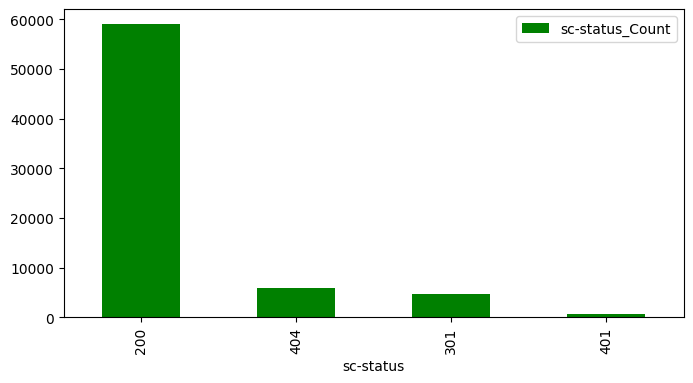

In [29]:
# Plot verificando os status
analise4_scstatus.plot(kind = 'bar', 
                       figsize = (8,4), 
                       color = 'green');

`Resultado da Análise:`

Existem 4 tipos de sc-status existentes no conjunto de dados. 

O sc-status **200** refere-se aos pedidos aceitos com sucesso pelo servidor. É esperado que esse status seja o que tenha maior volume nos dados.

Códigos **400** indicam que ocorreu um erro onde **404** refere-se à causa mais específica de um erro, como não encontrado, e **401** refere-se ao acesso negado. 

O código de resposta de status **301** indica que o recurso solicitado foi definitivamente movido para a URL fornecida pelos cabeçalhos. Um navegador redireciona para a nova URL e os mecanismos de pesquisa atualizam seus links para o recurso.

In [30]:
data_dict["cs-method"]

'Método HTTP utilizado'

In [31]:
analise4_csmethod = pd.DataFrame()

analise4_csmethod["cs-method_Counts"] = pd.DataFrame(dados['cs-method'].value_counts())
analise4_csmethod

,cs-method_Counts
cs-method,
GET,67202
POST,3113


`Resultado da Análise:`

Basicamente, POST é usado para enviar dados para um servidor e GET é usado para solicitar dados de um recurso especificado. Alto volume de requisições POST em um curto espaço de tempo podem indicar acesso suspeito.

### Análise 5 - Verificando Conexões do Tipo POST

Vamos filtrar os acessos com requisições de método POST e fazer um agrupamento por endereço IP do client

In [33]:
df_filtro = pd.DataFrame(dados)

df_filtro.drop(["s-ip", 
                "s-port", 
                "cs(User-Agent)", 
                "cs(Referer)",
                "sc-substatus",
                "sc-win32-status"], axis = 1, 
               inplace = True)

In [36]:
analise5 = df_filtro.loc[df_filtro['cs-method'] == 'POST'].groupby(pd.Grouper(key = 'c-ip', axis=0))['cs-method'].value_counts().reset_index(name = 'Counts')

analise5.sort_values(by = "Counts", ascending = False).head(10)

,c-ip,cs-method,Counts
1,103.211.182.34,POST,180
746,45.84.89.130,POST,67
127,160.116.57.249,POST,46
424,194.12.8.149,POST,11
315,185.97.213.168,POST,10
369,193.164.167.94,POST,10
95,154.14.15.237,POST,9
604,212.165.134.126,POST,8
388,193.24.26.211,POST,8
906,82.206.244.38,POST,8


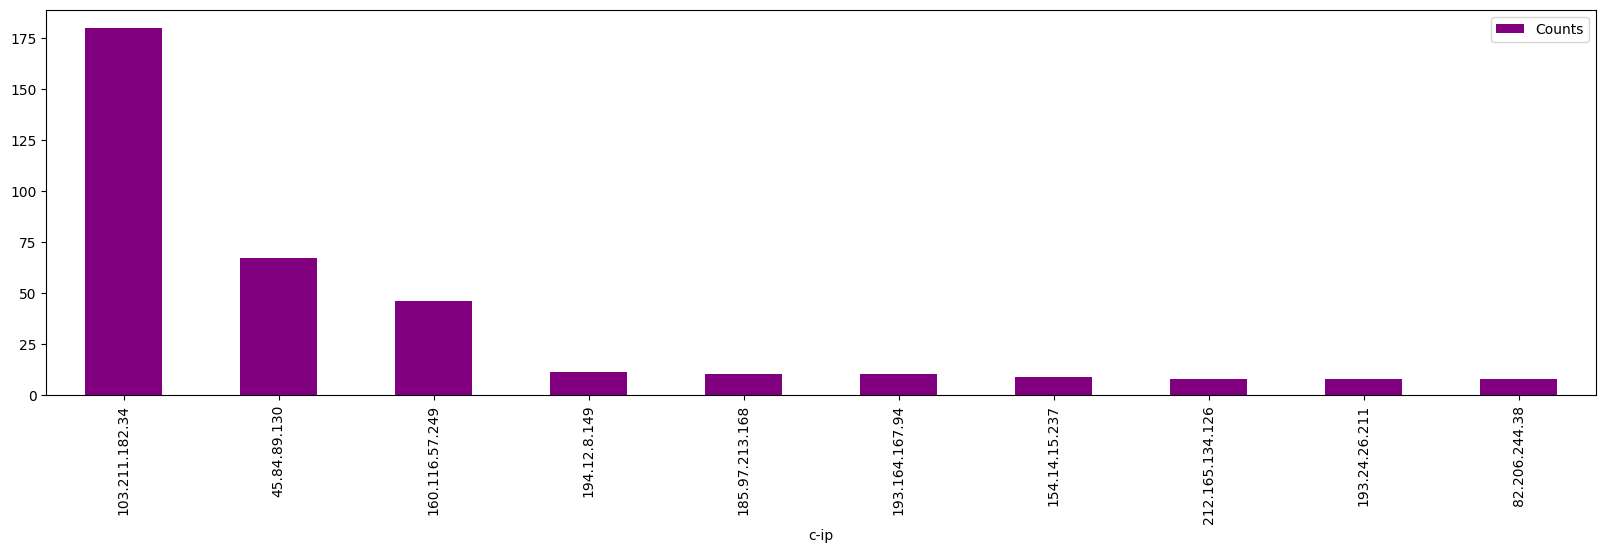

In [38]:
# Plot
analise5.sort_values(by = "Counts", 
                     ascending = False).head(10).plot(x = 'c-ip', 
                                                      y = 'Counts', 
                                                      kind = 'bar', 
                                                      figsize = (20,5), 
                                                      color = 'purple');

`Resultado da Análise:`

O gráfico mostra que 3 endereços ip foram os que tiveram maior número de acessos com requisições de método POST. Isso indica tentativa de login por força bruta para obter username e/ou senha. Vamos analisar isso em mais detalhes para a página **login.aspx**.

### Análise 6 - Verificando Tentativa de Login Por Força Bruta

Vamos verificar se está havendo tentativa de login por força bruta. Usaremos o dataframe df_filtro do item anterior como ponto de partida.

In [39]:
analise6 = df_filtro.loc[df_filtro['cs-uri-stem'] == 'login.aspx'].groupby(pd.Grouper(key = 'c-ip', 
                                                                                      axis = 0))['cs-uri-stem'].value_counts().reset_index(name = 'Counts')

In [42]:
analise6.sort_values(by = "Counts", asecending = False).head(10)

TypeError: DataFrame.sort_values() got an unexpected keyword argument 'asecending'

In [43]:
analise6.sort_values(by = "Counts", ascending = False).head(10)

,c-ip,cs-uri-stem,Counts
1,103.211.182.34,login.aspx,174
746,45.84.89.130,login.aspx,61
127,160.116.57.249,login.aspx,40
424,194.12.8.149,login.aspx,12
369,193.164.167.94,login.aspx,12
95,154.14.15.237,login.aspx,11
583,207.117.196.232,login.aspx,10
388,193.24.26.211,login.aspx,10
801,57.246.165.107,login.aspx,10
315,185.97.213.168,login.aspx,10


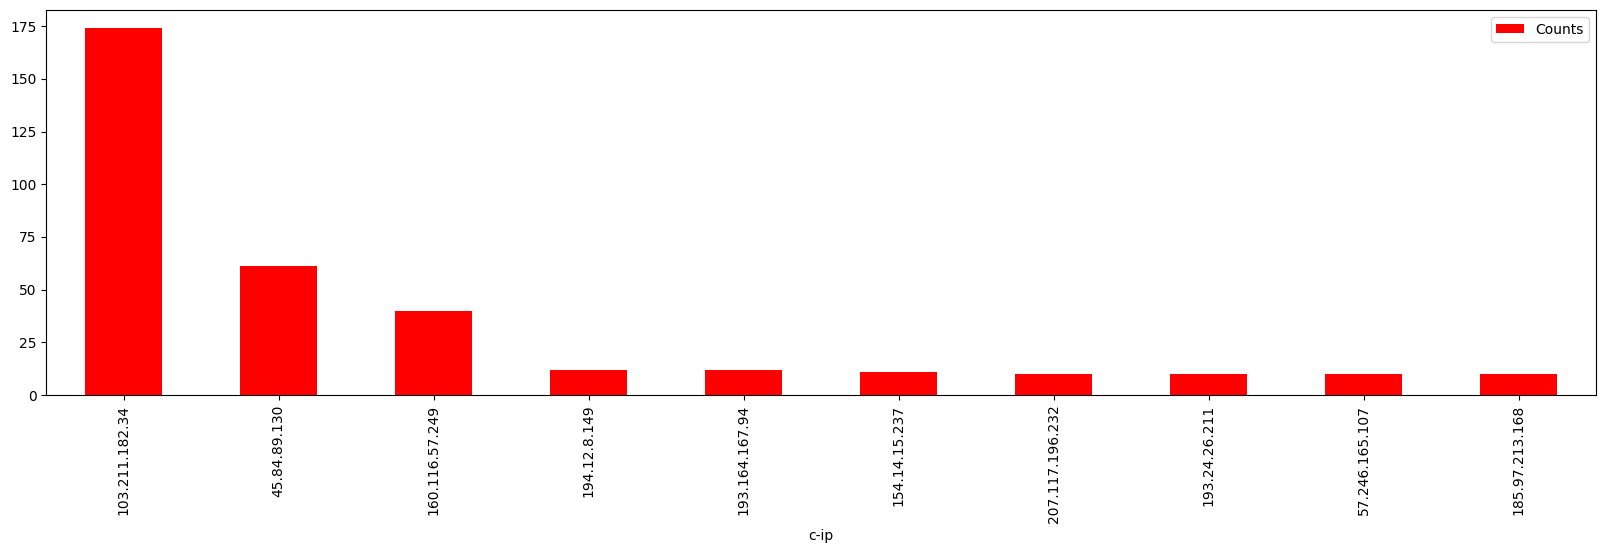

In [44]:
# Plot
analise6.sort_values(by = "Counts", 
                     ascending = False).head(10).plot(x = 'c-ip', 
                                                      y = 'Counts', 
                                                      kind = 'bar', 
                                                      figsize = (20,5), 
                                                      color = 'red');

`Resultado da Análise:`

O alto volume de acessos com requisição via método POST vem de 3 endereços IP. E as requisições são direcionadas para a página login.aspx. Isso indica que estão tentando acessar a página até descobrir as credenciais de acesso. Claramente tentativa de acesso por força bruta.

### Análise 7 - Página com Maior Número de Acessos com Status 401

Para os endereços IP com maior volume de acessos, vamos verificar qual página recebeu maior número de acessos com status 401. Usaremos o dataframe df_filtro do item anterior como ponto de partida.

In [45]:
df_filtro.head()

,date,time,cs-method,cs-uri-stem,cs-uri-query,cs-username,c-ip,sc-status,time-taken
0,2022-01-01,00:58:33,GET,smhirsxw.css,-,-,89.251.124.218,200,23
1,2022-01-01,00:58:33,GET,llipgydg.css,-,-,89.251.124.218,200,21
2,2022-01-01,00:58:33,GET,footer.css,-,-,89.251.124.218,200,26
3,2022-01-01,00:58:33,GET,index.aspx,-,-,89.251.124.218,301,21
4,2022-01-01,00:58:49,GET,fbuizasq.css,-,-,89.251.124.218,200,20


In [46]:
df_filtered = df_filtro[df_filtro['sc-status'] == 401]

In [47]:
# Conta as ocorrências de cada cs-uri-stem
analise7 = df_filtered['cs-uri-stem'].value_counts().reset_index()

In [48]:
# Renomeia as colunas para maior clareza
analise7.columns = ['cs-uri-stem', 'count']
analise7

,cs-uri-stem,count
0,login.aspx,683


In [49]:
# Filtra as linhas onde o c-ip corresponde a um dos IPs com mais acessos e sc-status é 401
df_filtered = df_filtro[(df_filtro['c-ip'].isin(['103.211.182.34', '45.84.89.130', '160.116.57.249'])) & (df_filtro['sc-status'] == 401)]

In [50]:
# Conta as ocorrências de cada cs-uri-stem para cada c-ip
analise7 = df_filtered.groupby(['c-ip', 'cs-uri-stem']).size().reset_index(name = 'count')

In [51]:
# Obtém o cs-uri-stem com o maior número de ocorrências de status 401 para cada c-ip
analise7_max = analise7.loc[analise7.groupby('c-ip')['count'].idxmax()]

In [52]:
print(analise7)

             c-ip cs-uri-stem  count
0  103.211.182.34  login.aspx    173
1  160.116.57.249  login.aspx     39
2    45.84.89.130  login.aspx     60


`Resultado da Análise:`
 
Há apenas uma página com status 401 e esta é a página mais acessada com erro 401 a partir de 3 endereços IP.

### Análise 8 - Verificando os Arquivos Mais Acessados na Aplicação Web

Vamos analisar os arquivos mais acessados pelo c-ip = 103.211.182.34

In [53]:
# Filtra as linhas onde o c-ip é igual a '103.211.182.34'
df_filtered = df_filtro[df_filtro['c-ip'] == '103.211.182.34']

In [54]:
# Agrupa por cs-uri-stem e sc-status, e conta as ocorrências
analise8 = df_filtered.groupby(['cs-uri-stem', 'sc-status']).size().reset_index(name = 'count')

In [55]:
# Ordena o resultado em ordem decrescente com base na contagem
analise8_sorted = analise8.sort_values(by = 'count', ascending = False)
analise8_sorted.head(5)

,cs-uri-stem,sc-status,count
16,login.aspx,401,173
29,transfer.aspx,200,12
5,favico.ico,200,7
18,main.css,200,6
30,transfer_complete.aspx,200,6


In [56]:
# Cria um dicionário
analise8_dict = {"cs-uri-stem": ["login.aspx", 
                                 "transfer.aspx", 
                                 "favico.ico", 
                                 "main.css", 
                                 "transfer_complete.aspx"],
                 "Count": [173,12,7,6,6],
                 "sc-status": [401,200,200,200,200]}

In [57]:
# Converte em dataframe
df_analise8 = pd.DataFrame(data = analise8_dict)
df_analise8

,cs-uri-stem,Count,sc-status
0,login.aspx,173,401
1,transfer.aspx,12,200
2,favico.ico,7,200
3,main.css,6,200
4,transfer_complete.aspx,6,200


Vamos resumir esse dataframe em duas partes: Acessos com código 401 e outros, e então criar um plot.

In [58]:
# Dataframe consolidado
df = pd.DataFrame({"Count": [173, 31],
                   'sc-status_&_uri_stem': ['401(login.aspx)', 'Outros']},
                  index = ['401(login.aspx)', 'Outros'])

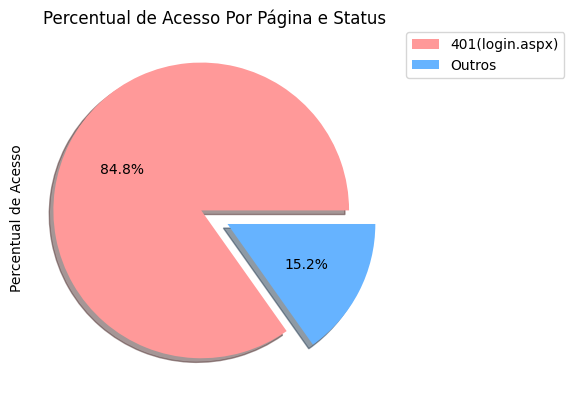

In [59]:
# Plot
colors = ['#ff9999','#66b3ff']
ax = df.plot(kind = "pie", 
             autopct = '%1.1f%%', 
             shadow = True, 
             explode = [0.1, 0.1], 
             colors = colors, 
             y = 'Count', 
             legend = True, 
             title = 'Percentual de Acesso Por Página e Status', 
             ylabel = 'Percentual de Acesso', 
             labeldistance = None)
ax.legend(bbox_to_anchor = (1, 1.02), loc = 'upper left')
plt.show()

`Resultado da Análise:`

A página de login é claramente o alvo dos acessos suspeitos.

## Conclusão

Os endereços IP abaixo apresentaram acessos suspeitos e maliciosos à aplicação web, tentando obter acesso por força bruta.

1. 103.211.182.34
2. 45.84.89.130
3. 160.116.57.249
    
A empresa pode entrar em contato com os provedores desses endereços IP a fim de obter mais detalhes ou mesmo bloquear os endereços.

## Modelagem Preditiva

Vamos construir um modelo RandomForest a fim de prever se uma determinada conexão reflete um acesso suspeito ou malicioso.

In [60]:
dados.head()

,date,time,s-ip,cs-method,cs-uri-stem,cs-uri-query,s-port,cs-username,c-ip,cs(User-Agent),cs(Referer),sc-status,sc-substatus,sc-win32-status,time-taken
0,2022-01-01,00:58:33,57.222.145.109,GET,smhirsxw.css,-,443,-,89.251.124.218,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,https://bankofpunk.local/index.aspx,200,0,0,23
1,2022-01-01,00:58:33,57.222.145.109,GET,llipgydg.css,-,443,-,89.251.124.218,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,https://bankofpunk.local/index.aspx,200,0,0,21
2,2022-01-01,00:58:33,57.222.145.109,GET,footer.css,-,443,-,89.251.124.218,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,https://bankofpunk.local/index.aspx,200,0,0,26
3,2022-01-01,00:58:33,57.222.145.109,GET,index.aspx,-,443,-,89.251.124.218,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,https://bankofpunk.local/index.aspx,301,0,0,21
4,2022-01-01,00:58:49,57.222.145.109,GET,fbuizasq.css,-,443,-,89.251.124.218,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...,https://bankofpunk.local/index.aspx,200,0,0,20


Criar rótulo de acesso suspeito (1) ou normal (0) com base em critérios definidos

Exemplo: status 401 é suspeito, outros são normais

In [61]:
dados['label'] = np.where(dados['sc-status'] == 401, 1, 0)

In [62]:
dados['label'].value_counts()

label
0    69632
1      683
Name: count, dtype: int64

- 1 é a classe positiva (acesso suspeito)
- 0 é a classe negativa (acesso não suspeito, ou seja, acesso normal)


In [63]:
# Selecionar features e target
X = dados[['c-ip', 'cs-uri-stem', 'cs(User-Agent)']]
y = dados['label']

X.head()

,c-ip,cs-uri-stem,cs(User-Agent)
0,89.251.124.218,smhirsxw.css,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...
1,89.251.124.218,llipgydg.css,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...
2,89.251.124.218,footer.css,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...
3,89.251.124.218,index.aspx,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...
4,89.251.124.218,fbuizasq.css,Mozilla/5.0+(Windows+NT+10.0;+Win64;+x64)+Appl...


In [64]:
# Convertendo variáveis categóricas em variáveis dummy
X = pd.get_dummies(X, drop_first = True)

In [65]:
# Dividindo os dados em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [66]:
# Treinando um modelo de Random Forest
modelo_dsa_v1 = RandomForestClassifier(n_estimators = 150, random_state = 42)

In [67]:
modelo_dsa_v1.fit(X_treino, y_treino)

RandomForestClassifier(n_estimators=150, random_state=42)

In [68]:
# Fazendo previsões e avaliando o modelo
y_pred = modelo_dsa_v1.predict(X_teste)
print(confusion_matrix(y_teste, y_pred))

[[20857    42]
 [  104    92]]


`Analisando o Efeito do Desbalanceamento de Classe`

In [69]:
print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20899
           1       0.69      0.47      0.56       196

    accuracy                           0.99     21095
   macro avg       0.84      0.73      0.78     21095
weighted avg       0.99      0.99      0.99     21095



**Precision**: Mede a proporção de verdadeiros positivos (TP) em relação a todas as previsões positivas feitas pelo modelo. É a capacidade do modelo de não rotular como positivo um exemplo que é negativo. Em termos simples, é a precisão das previsões positivas.

**Recall**: Mede a proporção de verdadeiros positivos (TP) em relação ao total de exemplos positivos reais. É a capacidade do modelo de encontrar todos os exemplos positivos.

Precision foca na qualidade das previsões positivas, enquanto Recall foca na quantidade de positivos capturados pelo modelo.

Se você deseja prever melhor a classe positiva, a Recall é a métrica mais importante. Ela mede a capacidade do modelo de identificar corretamente a maior parte dos exemplos positivos, ou seja, quantos dos casos positivos reais o modelo consegue prever corretamente.

Focar em Recall é essencial quando a prioridade é minimizar os falsos negativos (ou seja, garantir que o modelo não perca nenhum caso positivo). Isso é especialmente relevante em situações como diagnósticos médicos, onde é mais crítico identificar todos os casos de uma doença, mesmo que isso signifique alguns falsos positivos.

### Ajustando o Balanceamento de Classe

In [70]:
# Inicializando o modelo com class_weight='balanced', atribui pesos diferentes em cada classe
modelo_dsa_v2 = RandomForestClassifier(class_weight = 'balanced', n_estimators = 150, random_state = 42)

modelo_dsa_v2.fit(X_treino, y_treino)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

In [71]:
# Fazendo previsões e avaliando o modelo
y_pred = modelo_dsa_v2.predict(X_teste)
print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     20899
           1       0.37      0.76      0.50       196

    accuracy                           0.99     21095
   macro avg       0.69      0.87      0.75     21095
weighted avg       0.99      0.99      0.99     21095

